In [ ]:
import numpy as np
import plumed
import MDAnalysis as mda
import matplotlib.pyplot as plt

In [ ]:
import sys
sys.path.insert(0, "../Scripts")
from principle_curve import PrincipalCurve
from ensemblerefiner import EnsemblePathRefinerFast
from pathcv import PathCV
# from pgtest import PathGennieMD
from path_gennie import PathGennieMD
# from system import Simulation_obj

In [ ]:
pc = PrincipalCurve(
        n_images=150,
        # lam=0.5,
        n_iter=250,
        tol=1e-5,
        verbose=False)

(1055, 4)

In [ ]:
def pathRepresentative(ensembles, start = None, end = None):

    smooth_paths = []
    for i in range(len(ensembles)):
        cv_dim = ensembles[i].shape[-1]
        path = pc.fit(ensembles[i].reshape(-1, cv_dim))
        smooth_paths.append(path.reshape(-1, 1, cv_dim))

    refiner = EnsemblePathRefinerFast(hidden_dim=512, device="cuda:0")
    # 3. Fit the model to your trajectory list

    refiner.fit(
        trajectories=smooth_paths[:],
        epochs=50000,
        start=start,
        end=end,
        lr=5e-4,
        patience=50,
        smoothness_weight=1e-5,
        consensus_mode="median",
        verbosity=True,
    )

    return refiner.transform(n_points=100)

In [ ]:
def drive_along_path(
    num_paths=3,
    path_cv=None,
    sim=None,
    start_pos=None,
    box=None,
    TEMP=300.0,
    tau1=5,
    tau2=5,
    max_trial=15,
    max_cycle=5000,
    sigma=0.001,
    mode="target",
    project=None,
):
    ensemble = []

    # --------------------------------------------------
    # Projection function
    # --------------------------------------------------
    def target_pathcv_proj(pos, **kwargs):
        path_cv = kwargs['path_cv']
        box = kwargs['box']
        cv = project(pos, box=box)
        cv_dim = cv.shape[-1]
        s, z = path_cv.compute(cv.reshape(-1, cv_dim))
        return np.array([s, z])

    def convergence_fn(pos, **kwargs):

        path_cv = kwargs['path_cv']
        box = kwargs['box']
        target_s = kwargs['target_s']

        cv = target_pathcv_proj(
            pos,
            path_cv=path_cv,
            box=box
        )
        s, z = cv
        return (
            np.abs(s - target_s) < 0.03
            and np.abs(z) < 0.05
        )
    # --------------------------------------------------
    # Generate ensemble paths
    # --------------------------------------------------
    for i in range(num_paths):
        simulation = Simulation_obj()
        sim = simulation.simulation
        print(f"Generating ensemble path {i+1}/{num_paths}...")
        segment_start = start_pos.copy()
        full_traj = []
        n_segments = 1
        for j in range(n_segments):
            target_s = (j + 1) / n_segments
            print(f"  Segment {j+1}/{n_segments} | target s = {target_s:.2f}")
            pg = PathGennieMD(
                simulation=sim,
                projection_fn=target_pathcv_proj,
                projection_args={
                    'path_cv': path_cv,
                    'box': box
                },
                mode=mode,
                escape_direction="increase",
                target_projection=np.array([target_s, 0.0]),
                convergence_fn=convergence_fn,
                convergence_args={
                    'path_cv': path_cv,
                    'box': box,
                    'target_s': target_s,
                },
                temperature=TEMP,
                sigma=sigma,
            )

            traj, _ = pg.run(
                initial_pos=segment_start,
                tau1=tau1,
                tau2=tau2,
                max_trial=max_trial,
                max_cycle=max_cycle,
                save_freq=1,
                verbosity=2,
            )

            segment_start = traj[-1] / 10.0
            # Avoid duplicate frames
            if len(full_traj) == 0:
                full_traj.extend(traj)
            else:
                full_traj.extend(traj[1:])
        ensemble.append(np.array(full_traj) / 10.0)
    return ensemble

In [ ]:
class PlumedCVRunner:
    def __init__(self, n_atoms, plumed_input, cv_names, masses=None, log_file="plumed.log"):
        self.cv_names = list(cv_names)
        self.p = plumed.Plumed()

        self.p.cmd("setMDEngine", "python")
        self.p.cmd("setTimestep", 1.0)
        self.p.cmd("setKbT", 1.0)
        self.p.cmd("setNatoms", int(n_atoms))
        self.p.cmd("setLogFile", log_file)
        self.p.cmd("init")

        for line in plumed_input.strip().splitlines():
            line = line.strip()
            if not line or line.startswith("PRINT "):
                continue
            self.p.cmd("readInputLine", line)

        self.masses = np.asarray(
            np.ones(n_atoms, dtype=np.float64) if masses is None else masses,
            dtype=np.float64,
        )
        self.forces = np.zeros((n_atoms, 3), dtype=np.float64)
        self.virial = np.zeros((3, 3), dtype=np.float64)

        self.value_bufs = {}
        for name in self.cv_names:
            shape = np.zeros(1, dtype=np.int_)
            self.p.cmd(f"getDataRank {name}", shape)
            buf = np.zeros(1, dtype=np.float64)
            self.p.cmd(f"setMemoryForData {name}", buf)
            self.value_bufs[name] = buf

    def compute(self, positions_A, box_A=None, step=0):
        pos_nm = np.asarray(positions_A, dtype=np.float64) * 0.1

        if box_A is None:
            box_nm = np.zeros((3, 3), dtype=np.float64)
        else:
            box_nm = np.asarray(box_A, dtype=np.float64) * 0.1
            if box_nm.shape == (3,):
                box_nm = np.diag(box_nm)

        self.p.cmd("setStep", int(step))
        self.p.cmd("setMasses", self.masses)
        self.p.cmd("setPositions", pos_nm)
        self.p.cmd("setForces", self.forces)
        self.p.cmd("setVirial", self.virial)
        self.p.cmd("setBox", box_nm)
        self.p.cmd("calc")

        return np.array([self.value_bufs[name][0] for name in self.cv_names], dtype=np.float64)

def compute_cvs(u, runner):
    test_cv = []
    for ts in u.trajectory:
        coords = u.atoms.positions
        box = u.dimensions[:3]
        cvs = runner.compute(coords, box_A=box, step=0)
        test_cv.append(cvs)
    return np.array(test_cv)

In [ ]:
# OpenMM (use explicit imports; avoid *)
from openmm import (  # type: ignore
    LangevinMiddleIntegrator,
    MonteCarloBarostat,
    Platform,
    NonbondedForce,
    CMMotionRemover,
)
from openmm.app import (  # type: ignore
    PME,
    AllBonds,
    DCDReporter,
    StateDataReporter,
    GromacsGroFile,
    GromacsTopFile,
    Simulation,
)
from openmm.unit import (  # type: ignore
    amu,
    bar,
    femtoseconds,
    kelvin,
    nanometers,
    picosecond,
)
from openmmplumed import PlumedForce  # type: ignore


class Simulation_obj:
    def __init__(self, device=0, plumed_path="./pathcons.dat"):

        ffdir = "/home/dm/Soft/GMX26/share/gromacs/top"
        platform_name = "CUDA"

        # ============================================================
        # MDP equivalents
        # ============================================================

        # Temperature
        self.temperature = 300  # ref-t = 300

        # Electrostatics
        self.nonbondedMethod = PME               # coulombtype = PME
        self.nonbondedCutoff = 1.0 * nanometers  # rcoulomb = 1.0 / rvdw = 1.0
        self.ewaldErrorTolerance = 1e-5          # ewald-rtol = 1.e-5

        # Constraints
        self.constraints = AllBonds              # constraints = all-bonds
        self.rigidWater = True
        self.constraintTolerance = 1e-6

        # HMR (optional; NOT present in original mdp)
        self.hydrogenMass = 1.5 * amu

        # Integrator / thermostat
        self.timestep = 4.0 * femtoseconds       # dt = 0.002 ps

        # Approximate v-rescale thermostat
        # tau-t = 0.1 ps  -> gamma ~ 10/ps
        # But 1-5/ps is usually more stable in OpenMM
        self.friction = 1.0 / picosecond

        # Pressure coupling
        self.pressure = 1.0 * bar                # ref-p = 1.0
        self.barostat_frequency = 25             # typical OpenMM value

        # COM removal
        self.remove_com_frequency = 100          # nstcomm = 100

        # ============================================================
        # Load topology
        # ============================================================

        gro_file = GromacsGroFile(
            "/home/dm/Dibyendu/Trash/Deep-LDA_LigandBinding_SAMPL5-main/OAMe_G2/confout.gro"
        )

        top_file = GromacsTopFile(
            "/home/dm/Dibyendu/Trash/Deep-LDA_LigandBinding_SAMPL5-main/OAMe_G2/topol.top",
            periodicBoxVectors=gro_file.getPeriodicBoxVectors(),
            includeDir=ffdir,
        )

        # ============================================================
        # Integrator
        # ============================================================

        integrator = LangevinMiddleIntegrator(
            self.temperature * kelvin,
            self.friction,
            self.timestep,
        )

        integrator.setConstraintTolerance(self.constraintTolerance)

        # ============================================================
        # System creation
        # ============================================================

        system = top_file.createSystem(
            nonbondedMethod=self.nonbondedMethod,
            nonbondedCutoff=self.nonbondedCutoff,
            constraints=self.constraints,
            rigidWater=self.rigidWater,
            ewaldErrorTolerance=self.ewaldErrorTolerance,
            hydrogenMass=self.hydrogenMass,
        )

        # ============================================================
        # Dispersion correction
        # DispCorr = EnerPres
        # ============================================================

        for force in system.getForces():
            if isinstance(force, NonbondedForce):
                force.setUseDispersionCorrection(True)

        # ============================================================
        # COM motion removal
        # comm-mode = linear
        # nstcomm = 100
        # ============================================================

        system.addForce(
            CMMotionRemover(self.remove_com_frequency)
        )

        if plumed_path is not None:
            with open(plumed_path) as f:
                plumed_script = f.read()

            plumed_force = PlumedForce(plumed_script)
            system.addForce(plumed_force)

        # ============================================================
        # Platform
        # ============================================================

        if platform_name == "CUDA":

            platform = Platform.getPlatformByName("CUDA")

            properties = {
                "Precision": "mixed",
                "DeviceIndex": str(device),
            }

            self.simulation = Simulation(
                top_file.topology,
                system,
                integrator,
                platform,
                properties,
            )

        else:

            platform = Platform.getPlatformByName("CPU")

            self.simulation = Simulation(
                top_file.topology,
                system,
                integrator,
                platform,
            )

        # ============================================================
        # Positions
        # ============================================================

        self.simulation.context.setPositions(gro_file.positions)

        # ============================================================
        # gen_vel = yes
        # ============================================================

        self.simulation.context.setVelocitiesToTemperature(
            self.temperature * kelvin
        )


# sim = Simulation_obj()


In [ ]:
source = np.array([[0.62136948, 0.43476191, 0.51918511, 0.59272539]])
target = np.array([[1.49131554, 2.01986178, 2.18649256, 1.76629954]])
# target = np.array([[2.01986178, 1.76629954]])

# sim = Simulation_obj()
u = mda.Universe("box.gro")
runner = PlumedCVRunner(
    n_atoms=u.atoms.n_atoms,
    plumed_input=open("plumed.dat").read(),
    cv_names=["V1", "V2","V3", "cyl.z"],
    masses=u.atoms.masses,
)
def project(positions, **kwargs):
    box = kwargs['box']
    cvs = runner.compute(positions, box_A=box, step=0)
    return cvs
def convergence_fn(pos, **kwargs):
    box = kwargs['box']
    cv = project(pos,  box = box)
    return np.linalg.norm(cv - target) < 0.05

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dm/Soft/miniconda3/envs/torch311/lib/libplumedKernel.so" +++


In [ ]:
test_u = mda.Universe("box.gro", "./PCA_Cone/pg_init_trial_1.xtc")
test_u.trajectory[107]
initial_positions = 0.1*test_u.atoms.positions
box = test_u.dimensions[:3]

In [ ]:
traj_list = []
for i in range(1):
    pg = PathGennieMD(
        simulation=sim.simulation,
        projection_fn=project,
        projection_args = {'box':box},
        mode="target",
        escape_direction = "increase",
        target_projection=target, # Target s = 1.0
        convergence_fn=convergence_fn,
        convergence_args = {'box':box},
        temperature=300,
        sigma=0.05)
    traj, _ = pg.run(
        initial_pos=initial_positions,
        tau1=10,
        tau2=5,
        max_trial=15,
        max_cycle=5000,
        save_freq=1,
        verbosity=2)
    traj_list.append(traj)

PathGennie:   0%|          | 0/5000 [00:00<?, ?it/s]

Cycle    0: metric=-2.7040 (best of 15)
Cycle   10: metric=-2.6657 (best of 15)
Cycle   20: metric=-2.6084 (best of 15)
Cycle   30: metric=-2.5816 (best of 15)
Cycle   40: metric=-2.5616 (best of 15)
Cycle   50: metric=-2.5254 (best of 15)
Cycle   60: metric=-2.4413 (best of 15)
Cycle   70: metric=-2.4181 (best of 15)
Cycle   80: metric=-2.3535 (best of 15)
Cycle   90: metric=-2.2736 (best of 15)
Cycle  100: metric=-2.1930 (best of 15)
Cycle  110: metric=-2.0861 (best of 15)
Cycle  120: metric=-2.0475 (best of 15)
Cycle  130: metric=-1.9135 (best of 15)
Cycle  140: metric=-1.9341 (best of 15)
Cycle  150: metric=-1.9965 (best of 15)
Cycle  160: metric=-1.9719 (best of 15)
Cycle  170: metric=-1.9660 (best of 15)
Cycle  180: metric=-1.9173 (best of 15)
Cycle  190: metric=-1.8242 (best of 15)
Cycle  200: metric=-1.8587 (best of 15)
Cycle  210: metric=-1.7522 (best of 15)
Cycle  220: metric=-1.5923 (best of 15)
Cycle  230: metric=-1.5359 (best of 15)
Cycle  240: metric=-1.3543 (best of 15)


In [ ]:
genpos= traj
gencv = []
for positions in genpos[:]:
    gencv.append(project(positions, box = box))

In [ ]:
init_cv0 = np.array(gencv)

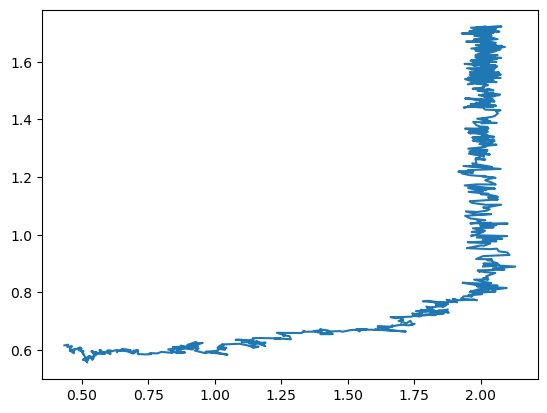

In [ ]:
plt.plot(init_cv0[:, 1], init_cv0[:, 3], label="Generated Path")

In [ ]:
initial_rep0 =  pathRepresentative([init_cv0], start = source, end = target)

Epoch     0 | Loss 1.161e-01 | Data 1.161e-01 | Smooth 3.569e-12
Epoch   200 | Loss 3.315e-03 | Data 3.315e-03 | Smooth 1.081e-08
Epoch   400 | Loss 1.662e-03 | Data 1.662e-03 | Smooth 3.658e-08
Epoch   600 | Loss 1.489e-03 | Data 1.489e-03 | Smooth 5.268e-08
Epoch   800 | Loss 1.439e-03 | Data 1.439e-03 | Smooth 5.690e-08
Epoch  1000 | Loss 1.404e-03 | Data 1.404e-03 | Smooth 5.871e-08
Epoch  1200 | Loss 1.362e-03 | Data 1.362e-03 | Smooth 5.996e-08
Epoch  1400 | Loss 1.296e-03 | Data 1.296e-03 | Smooth 6.376e-08
Epoch  1600 | Loss 1.220e-03 | Data 1.220e-03 | Smooth 7.212e-08
Epoch  1800 | Loss 1.158e-03 | Data 1.158e-03 | Smooth 8.545e-08
Epoch  2000 | Loss 1.110e-03 | Data 1.110e-03 | Smooth 1.027e-07
Epoch  2200 | Loss 1.071e-03 | Data 1.071e-03 | Smooth 1.218e-07
Epoch  2400 | Loss 1.033e-03 | Data 1.033e-03 | Smooth 1.416e-07
Epoch  2600 | Loss 9.833e-04 | Data 9.833e-04 | Smooth 1.612e-07
Epoch  2800 | Loss 9.025e-04 | Data 9.025e-04 | Smooth 1.851e-07
Epoch  3000 | Loss 8.142e

In [ ]:
source = np.array([[0.43476191, 0.59272539]])
target = np.array([[2.01986178, 1.76629954]])
initial_rep8 = np.load("./initial_rep7_.npy")[:,:,[1,-1]].reshape(-1, 1, 2)#initial_rep8 =  pathRepresentative(new_cv, start = source, end = target)
initial_rep8 =  pathRepresentative([initial_rep8.reshape(-1, 2)], start = source, end = target)

Epoch     0 | Loss 7.946e-02 | Data 7.946e-02 | Smooth 6.446e-12
Epoch   200 | Loss 7.205e-04 | Data 7.205e-04 | Smooth 3.602e-09
Epoch   400 | Loss 1.446e-04 | Data 1.446e-04 | Smooth 4.427e-09
Epoch   600 | Loss 1.042e-04 | Data 1.042e-04 | Smooth 4.396e-09
Epoch   800 | Loss 8.009e-05 | Data 8.009e-05 | Smooth 4.542e-09
Epoch  1000 | Loss 6.337e-05 | Data 6.337e-05 | Smooth 4.798e-09
Epoch  1200 | Loss 4.831e-05 | Data 4.831e-05 | Smooth 5.208e-09
Epoch  1400 | Loss 3.082e-05 | Data 3.082e-05 | Smooth 6.134e-09
Epoch  1600 | Loss 2.483e-05 | Data 2.483e-05 | Smooth 7.125e-09
Early stopping at epoch 1766


In [ ]:
# initial_rep0 = np.load("./initial_rep0.npy")

In [ ]:
np.save("initial_rep8.npy", initial_rep8)

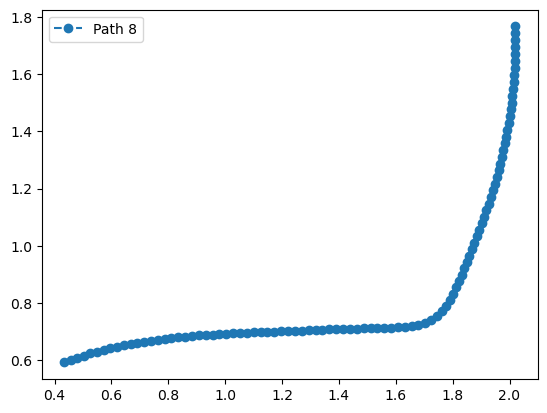

In [ ]:
# plt.plot(initial_rep0[:, :, 1], initial_rep0[:,:, -1], label="Path Representative")
# # plt.plot(test[:, :, 1], test[:,:, -1], label="Path Representative")
# # plt.plot(initial_rep2[:, :, 1], initial_rep2[:,:, -1], label="Path Representative")
# plt.plot(initial_rep1[:, :, 1], initial_rep1[:,:, -1], label="Path Representative")
# plt.plot(initial_rep2[:, :, 1], initial_rep2[:,:, -1], label="Path Representative")
# plt.plot(initial_rep3[:, :, 1], initial_rep3[:,:, -1], label="Path Representative")
# plt.plot(initial_rep4[:, :, 1], initial_rep4[:,:, -1], label="Path Representative")
# plt.plot(initial_rep5[:, :, 1], initial_rep5[:,:, -1], label="Path Representative")
plt.plot(initial_rep8[:, :, 0], initial_rep8[:,:, -1], label="Path 8", ls = "--", marker = "o")
plt.legend()
# plt.plot(new_cv[0][:, 1], new_cv[0][:, -1], label="Generated Path")

In [ ]:
np.save("./initial_rep7_.npy", initial_rep8)

In [ ]:
# from pathcv import PathCV
path_cv = PathCV(initial_rep8[::2].reshape(initial_rep8[::2].shape[0], 1, 4),
normalize_output=True,)# lambda_mode = "manual", lambda_value = 2000)

In [ ]:
path_cv.lam

np.float64(348.9016586359457)

In [ ]:
ensembles = drive_along_path(
    num_paths=5,
    path_cv=path_cv,
    sim=sim.simulation,
    start_pos=initial_positions,
    TEMP=300.0,
    tau1=15,
    tau2=30,
    max_trial=10,
    max_cycle=5000,
    sigma=0.05,
    project=project)

PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:23:39
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/dm/Soft/miniconda3/envs/torch311/lib/plumed
PLUMED: For installed feature, see /home/dm/Soft/miniconda3/envs/torch311/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: OpenMM
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6520
PLUMED: File suffix: 
PLUMED: Timestep: 0.004000
PLUMED: KbT has not been set by the MD engine
PLUMED: It should be set by hand where needed
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriate!
PLUMED: Fini

PathGennie:   0%|          | 0/5000 [00:00<?, ?it/s]

Cycle    0: metric=-0.9878 (best of 10)
Cycle   10: metric=-0.9647 (best of 10)
Cycle   20: metric=-0.9704 (best of 10)
Cycle   30: metric=-0.9659 (best of 10)
Cycle   40: metric=-0.9553 (best of 10)
Cycle   50: metric=-0.9524 (best of 10)
Cycle   60: metric=-0.9694 (best of 10)
Cycle   70: metric=-0.9558 (best of 10)
Cycle   80: metric=-0.9680 (best of 10)
Cycle   90: metric=-0.9567 (best of 10)
Cycle  100: metric=-0.9645 (best of 10)
Cycle  110: metric=-0.9621 (best of 10)
Cycle  120: metric=-0.9549 (best of 10)
Cycle  130: metric=-0.9605 (best of 10)
Cycle  140: metric=-0.9487 (best of 10)
Cycle  150: metric=-0.9765 (best of 10)
Cycle  160: metric=-0.9667 (best of 10)
Cycle  170: metric=-0.9655 (best of 10)
Cycle  180: metric=-0.9752 (best of 10)
Cycle  190: metric=-0.9601 (best of 10)
Cycle  200: metric=-0.9669 (best of 10)
Cycle  210: metric=-0.9445 (best of 10)
Cycle  220: metric=-0.9688 (best of 10)
Cycle  230: metric=-0.9601 (best of 10)
Cycle  240: metric=-0.9721 (best of 10)


PathGennie:   0%|          | 0/5000 [00:00<?, ?it/s]

Cycle    0: metric=-0.9910 (best of 10)
Cycle   10: metric=-0.9751 (best of 10)
Cycle   20: metric=-0.9690 (best of 10)
Cycle   30: metric=-0.9908 (best of 10)
Cycle   40: metric=-0.9706 (best of 10)
Cycle   50: metric=-0.9807 (best of 10)
Cycle   60: metric=-0.9804 (best of 10)
Cycle   70: metric=-0.9667 (best of 10)
Cycle   80: metric=-0.9617 (best of 10)
Cycle   90: metric=-0.9714 (best of 10)
Cycle  100: metric=-0.9707 (best of 10)
Cycle  110: metric=-0.9715 (best of 10)
Cycle  120: metric=-0.9804 (best of 10)
Cycle  130: metric=-0.9831 (best of 10)
Cycle  140: metric=-0.9581 (best of 10)
Cycle  150: metric=-0.9548 (best of 10)
Cycle  160: metric=-0.9490 (best of 10)
Cycle  170: metric=-0.9340 (best of 10)
Cycle  180: metric=-0.9439 (best of 10)
Cycle  190: metric=-0.9498 (best of 10)
Cycle  200: metric=-0.9446 (best of 10)
Cycle  210: metric=-0.9178 (best of 10)
Cycle  220: metric=-0.9354 (best of 10)
Cycle  230: metric=-0.8637 (best of 10)
Cycle  240: metric=-0.8554 (best of 10)


...

Cycle    0: metric=-0.9792 (best of 10)
Cycle   10: metric=-0.9756 (best of 10)
Cycle   20: metric=-0.9644 (best of 10)
Cycle   30: metric=-0.9316 (best of 10)
Cycle   40: metric=-0.9435 (best of 10)
Cycle   50: metric=-0.9396 (best of 10)
Cycle   60: metric=-0.9170 (best of 10)
Cycle   70: metric=-0.9324 (best of 10)
Cycle   80: metric=-0.8969 (best of 10)
Cycle   90: metric=-0.8886 (best of 10)
Cycle  100: metric=-0.9047 (best of 10)
Cycle  110: metric=-0.9042 (best of 10)
Cycle  120: metric=-0.9446 (best of 10)
Cycle  130: metric=-0.9468 (best of 10)
Cycle  140: metric=-0.9578 (best of 10)
Cycle  150: metric=-0.9456 (best of 10)
Cycle  160: metric=-0.9458 (best of 10)
Cycle  170: metric=-0.9524 (best of 10)
Cycle  180: metric=-0.9497 (best of 10)
Cycle  190: metric=-0.9388 (best of 10)
Cycle  200: metric=-0.9485 (best of 10)
Cycle  210: metric=-0.9599 (best of 10)
Cycle  220: metric=-0.9586 (best of 10)
Cycle  230: metric=-0.9598 (best of 10)
Cycle  240: metric=-0.9534 (best of 10)


PathGennie:   0%|          | 0/5000 [00:00<?, ?it/s]

Cycle    0: metric=-0.9874 (best of 10)
Cycle   10: metric=-0.9697 (best of 10)
Cycle   20: metric=-0.9871 (best of 10)
Cycle   30: metric=-0.9728 (best of 10)
Cycle   40: metric=-0.9730 (best of 10)
Cycle   50: metric=-0.9700 (best of 10)
Cycle   60: metric=-0.9572 (best of 10)
Cycle   70: metric=-0.9514 (best of 10)
Cycle   80: metric=-0.9439 (best of 10)
Cycle   90: metric=-0.9571 (best of 10)
Cycle  100: metric=-0.9308 (best of 10)
Cycle  110: metric=-0.9565 (best of 10)
Cycle  120: metric=-0.9538 (best of 10)
Cycle  130: metric=-0.9535 (best of 10)
Cycle  140: metric=-0.9442 (best of 10)
Cycle  150: metric=-0.9640 (best of 10)
Cycle  160: metric=-0.9584 (best of 10)
Cycle  170: metric=-0.9772 (best of 10)
Cycle  180: metric=-0.9176 (best of 10)
Cycle  190: metric=-0.9569 (best of 10)
Cycle  200: metric=-0.9691 (best of 10)
Cycle  210: metric=-0.9601 (best of 10)
Cycle  220: metric=-0.9731 (best of 10)
Cycle  230: metric=-0.9723 (best of 10)
Cycle  240: metric=-0.9864 (best of 10)


PathGennie:   0%|          | 0/5000 [00:00<?, ?it/s]

Cycle    0: metric=-0.9844 (best of 10)
Cycle   10: metric=-0.9896 (best of 10)
Cycle   20: metric=-0.9530 (best of 10)
Cycle   30: metric=-0.9376 (best of 10)
Cycle   40: metric=-0.9271 (best of 10)
Cycle   50: metric=-0.9474 (best of 10)
Cycle   60: metric=-0.8954 (best of 10)
Cycle   70: metric=-0.9306 (best of 10)
Cycle   80: metric=-0.8161 (best of 10)
Cycle   90: metric=-0.8340 (best of 10)
Cycle  100: metric=-0.7231 (best of 10)
Cycle  110: metric=-0.6194 (best of 10)
Cycle  120: metric=-0.7217 (best of 10)
Cycle  130: metric=-0.3689 (best of 10)
Cycle  140: metric=-0.3150 (best of 10)
Cycle  150: metric=-0.3110 (best of 10)
Cycle  160: metric=-0.3099 (best of 10)
Cycle  170: metric=-0.3175 (best of 10)
Cycle  180: metric=-0.2900 (best of 10)
Cycle  190: metric=-0.2593 (best of 10)
Cycle  200: metric=-0.2635 (best of 10)
Cycle  210: metric=-0.2592 (best of 10)
Cycle  220: metric=-0.2404 (best of 10)
Cycle  230: metric=-0.2631 (best of 10)
Cycle  240: metric=-0.2443 (best of 10)


In [ ]:
new_cv = []
for i in range(5):
    genpos= ensembles[i]
    if len(genpos) < 5000:
        gencv = []
        for positions in genpos[:]:
            gencv.append(project(positions*10.0, box = box))
        new_cv.append(np.array(gencv))

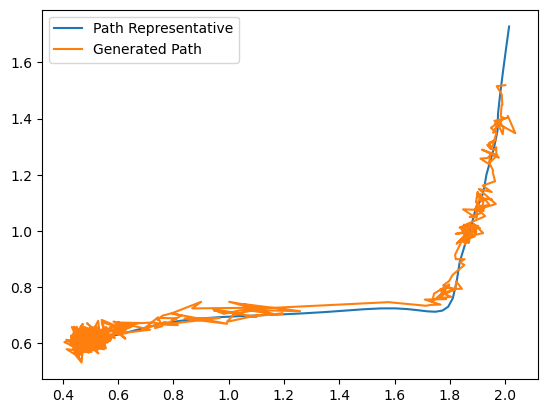

In [ ]:
# plt.plot(new_cv[1][:, 1], new_cv[1][:, -1], label="Path 1")
plt.plot(initial_rep4[:, :, 1][::2], initial_rep4[:,:, -1][::2], label="Path Representative")
plt.plot(new_cv[1][:, 1], new_cv[1][:, -1], label="Generated Path")
# plt.plot(new_cv[1][:, 1], new_cv[1][:, -1], label="Path 2")
# plt.plot(new_cv[2][:, 1], new_cv[2][:, -1], label="Path 3")
plt.legend()
# plt.plot(f_cvs[0][:, 1], f_cvs[0][:, -1], label="Path Representative")


In [ ]:
initial_rep0[0][0]

array([0.62136948, 0.43476191, 0.51918513, 0.5927254 ])

In [ ]:
def genplumed(x):
    V1 = x[0]
    V2 = x[1]
    V3 = x[2]
    z = x[3]
    template = f"""REMARK ARG=V1,V2,V3,cyl.z V1={V1} V2={V2} V3={V3} cyl.z={z}
END\n"""
    return template

In [ ]:
import numpy as np
# path = np.load("..npy")
new_path = np.load("initial_rep8.npy")

In [ ]:
new_path.shape

(100, 1, 2)

In [ ]:
def genplumedpath(x):
    V1 = x[0]
    V2 = x[1]
    V3 = x[2]
    z = x[3]
    template = f"""REMARK ARG=V1,V2,V3,cyl.z  V2={V1}  V2={V2}  V3={V3}  cyl.z={z}
END\n"""
    return template

with open("./process_wet_path.pdb", "w") as f:
    for i in range(0, len(path),2):
        f.write(genplumedpath(path[i][0]))

In [ ]:
def genplumedpath(x):
    V2, z = x

    return f"""REMARK ARG=V2,cyl.z V2={V2:.6f} cyl.z={z:.6f}
END
"""

with open("process_wet_path.pdb", "w") as f:
    for i in range(0, len(new_path), 2):
        f.write(genplumedpath(new_path[i][0]))

In [ ]:
mfep_wet = np.load("mfep_path_wet.npy")[::10]

In [ ]:
with open("mfep_wet_path.pdb", "w") as f:
    for i in range(len(mfep_wet)):
        f.write(genplumedpathmfep(mfep_wet[i]))

In [ ]:
with open("unprocess_wet_path.pdb", "w") as f:
    for i in range(len(initial_rep0)):
        f.write(genplumedpath(initial_rep0[i][0]))

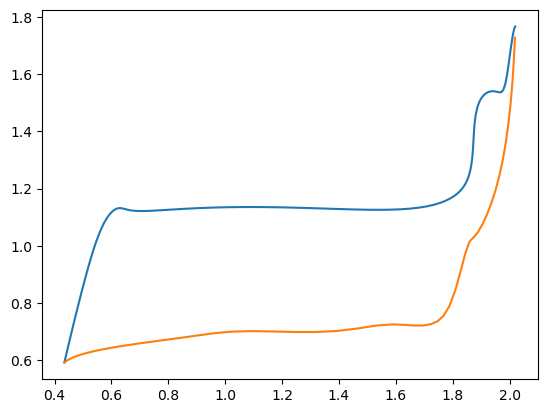

In [ ]:
plt.plot(initial_rep0[:, :, 1], initial_rep0[:,:, -1], label="Path Representative")
plt.plot(initial_rep8[:, :, 1][::2], initial_rep8[:,:, -1][::2], label="Path Representative")

In [ ]:
with open("./process_wet_path.pdb", "w") as f:
    for i in range(0, len(initial_rep8),2):
        f.write(genplumedpath(initial_rep8[i][0]))

In [ ]:
with open("path.pdb", "w") as f:
    for i in range(0, len(initial_rep8),2):
        f.write(genplumed(initial_rep8[i][0]))

In [ ]:
def filter_paths(cv, path_cv):
    s, z = np.array([path_cv.compute(cv[i].reshape(-1, 4)) for i in range(len(cv))]).T

    n = len(s)
    dp = np.full(n, np.inf)
    prev = np.full(n, -1)

    dp[0] = 0

    lambda_reward = 0.5
    max_jump = 20
    backward_penalty = 10

    for i in range(n):
        for j in range(i+1, min(n, i+max_jump)):
            penalty = 0
            if s[j] < s[i]:
                penalty += backward_penalty

            cost = dp[i] + penalty + abs(z[j] - z[i]) - lambda_reward

            if cost < dp[j]:
                dp[j] = cost
                prev[j] = i

    # force path to end
    idx = n - 1

    path = []
    while idx != -1:
        path.append(idx)
        idx = prev[idx]

    path = path[::-1]

    cummax = np.maximum.accumulate(s)
    mask = np.concatenate([[True], s[1:] > cummax[:-1]])
    return cv[mask]

In [ ]:
f_cvs = [filter_paths(new_cv[i], path_cv) for i in range(len(new_cv))]